# Proyecto de Estructuras de Datos

Para esta libreta, se tiene contemplado que la función de recolección de datos se encuentra en archivos .py en la carpeta src/ Estos archivos se ejecutan en terminal la libreta llama a los archivos resultantes almacenados en data/

## Configuración Inicial
Se realizan configuraciones iniciales para comenzar a cargar datos desde la API de Semantic Scholar.
Si se obtiene una API KEY válida, puede comenzarse la extracción de datos y almacenamiento de archivos en formato .csv
Todos los documentos .csv vienen por defecto en la carpeta de data, listos para ser usados por las funciones de construcción y análisis del grafo

In [17]:
import os
from dotenv import load_dotenv

load_dotenv()

SEMANTIC_SCHOLAR_API_KEY = os.getenv("SEMANTIC_SCHOLAR_API_KEY")
API_URL = "https://api.semanticscholar.org/graph/v1/paper/search"

if SEMANTIC_SCHOLAR_API_KEY:
    HEADERS = {"x-api-key": SEMANTIC_SCHOLAR_API_KEY}
    USE_API = True
    print("API key encontrada. Se podrá recolectar desde Semantic Scholar.")
else:
    HEADERS = {}
    USE_API = False
    print("No se encontró API key. Se usarán los CSV locales ya generados.")

API key encontrada. Se podrá recolectar desde Semantic Scholar.


## Recolección de Datos
Se inicial las operaciones para poder obtener los papers necesarios para el vaciado de autores y relaciones de trabajo
Primero se cargan librerías y directorios donde estarán almacenados los archivos tras la recolección

In [20]:
import sys
import os
sys.path.insert(0, os.getcwd())
import time
import requests
import pandas as pd

#Archivos y constantes para el proyecto
DATA_DIR = os.path.join(os.getcwd(), "data")
RAW_PAPER_FILE = os.path.join(DATA_DIR, "raw_papers.csv")
PROCESSED_PAPER_FILE = os.path.join(DATA_DIR, "processed_papers.csv")
AUTHORS_FILE = os.path.join(DATA_DIR, "authors.csv")

#Palabras clave para búsqueda de artículos dentro de la API
QUERIES = [
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "neural networks"
]

Se definen las funciones principales para la recolección de datos

In [28]:
def create_data_dir():
    os.makedirs(DATA_DIR, exist_ok=True)

#Consulta de artículos
def fetch_papers(query, limit=25):
    params = {
        "query": query,
        "limit": limit,
        "fields": "paperId,title,year,authors"
    }
    try: 
        response = requests.get(API_URL, params=params, headers=HEADERS, timeout=30)
        print(f"Consulta: {query} - Estatus: {response.status_code}")
        print (f"Respuesta: {response.status_code}")  
        #El número de respuesta 200 es una consulta exitosa
        if response.status_code ==200:
            return response.json().get("data", [])
        #El número de respuesta 429 notifica que se ha llegado al límite de requests
        if response.status_code == 429:
            print("Límite de tasa alcanzado. Esperando 60 segundos...")
            time.sleep(60)
            return fetch_papers(query, limit)
    except requests.exceptions.RequestException as e:
        print(f"Error al consultar la API: {e}")
    return []

#Formato de artículos guardados sin aplicar ningún filtro
def save_raw_data():
    all_papers = []
    for query in QUERIES:
        papers = fetch_papers(query,limit=25)
        for paper in papers:
            paper["query_used"] = query
            all_papers.append(paper)
        print(f"Artículos obtenidos: {len(papers)}")
        print("="*40)
        time.sleep(1)  # Para evitar exceder el límite de tasa
    
    return all_papers

#Aplicación de filtros para almacenar únicamente la información relevante:
#- Identificación del artículo (paperId)
#- Título del artículo (title)
#- Año de publicación (year)
#- Lista de autores (authors)

def clean_data(papers):
    cleaned = []
    for paper in papers:
        paper_id = paper.get("paperId")
        title = paper.get("title")
        year = paper.get("year")
        authors = paper.get("authors", [])
        
        if not paper_id or not title or not year:
            print(f"Artículo ignorado (datos faltantes): {paper}")
            continue
        if not isinstance(authors, list) or len(authors) < 2:
            print(f"Artículo ignorado (autores insuficientes): {title}")
            continue
        cleaned.append({
            "paperId": paper_id,
            "title": title,
            "year": year,
            "authors": authors
        })   
    df_clean = pd.DataFrame(cleaned)
    if not df_clean.empty:
         df_clean = df_clean.drop_duplicates(subset=["paperId"])
    return df_clean


#De los artículos obtenidos, se filtran los autores con sus posteriores campos de identificación
def extract_authors(papers):
    authors = []
    for _, paper in papers.iterrows():
        for author in paper["authors"]:
            author_id = author.get("authorId")
            name = author.get("name")
            if author_id and name:
                authors.append({"authorId": author_id, "name": name})
    df_authors = pd.DataFrame(authors)
    if not df_authors.empty:
        df_authors = df_authors.drop_duplicates(subset=["authorId"])
    # Limitar el número de autores guardados para evitar conjuntos demasiado grandes
    if not df_authors.empty:
        df_authors = df_authors
    return df_authors
 
#Función principal que ejecuta todo el proceso de recolección, limpieza y extracción de datos, además de guardar los resultados en archivos CSV para su posterior análisis. Se incluyen mensajes de impresión para monitorear el progreso y la cantidad de datos obtenidos en cada etapa.
def run_collection():
    create_data_dir()
    raw_papers = save_raw_data()
    df_raw = pd.DataFrame(raw_papers)
    df_raw.to_csv(RAW_PAPER_FILE, index=False, encoding="utf-8-sig")
    df_cleaned = clean_data (raw_papers)
    df_cleaned.to_csv(PROCESSED_PAPER_FILE, index=False, encoding="utf-8-sig")
    print (f"Articulos limpios obtenidos: {len(df_cleaned)}")
    df_authors = extract_authors(df_cleaned)
    df_authors.to_csv(AUTHORS_FILE, index=False, encoding="utf-8-sig")
    print (f"Autores extraidos: {len(df_authors)}")
    print("Recoleccion terminada")

Se llama a la función y comienza la recolección de datos desde la API

In [29]:
run_collection()

Consulta: artificial intelligence - Estatus: 200
Respuesta: 200
Artículos obtenidos: 25
Consulta: machine learning - Estatus: 200
Respuesta: 200
Artículos obtenidos: 25
Consulta: deep learning - Estatus: 200
Respuesta: 200
Artículos obtenidos: 25
Consulta: neural networks - Estatus: 200
Respuesta: 200
Artículos obtenidos: 25
Artículo ignorado (autores insuficientes): Explanation in Artificial Intelligence: Insights from the Social Sciences
Artículo ignorado (autores insuficientes): High-performance medicine: the convergence of human and artificial intelligence
Artículo ignorado (autores insuficientes): Adaptation in Natural and Artificial Systems: An Introductory Analysis with Applications to Biology, Control, and Artificial Intelligence
Artículo ignorado (autores insuficientes): Is it artificial intelligence or real?
Artículo ignorado (autores insuficientes): Machine Learning: Algorithms, Real-World Applications and Research Directions
Artículo ignorado (autores insuficientes): Stop E

## Construcción de edges 
Se realizan imports y se definen constantes para establecer directorios

In [38]:
import os
import ast
import pandas as pd
from itertools import combinations
from collections import defaultdict


DATA_DIR = os.path.join(os.getcwd(), "data")
CLEAN_PAPERS_FILE = os.path.join(DATA_DIR, "processed_papers.csv")
AUTHORS_FILE = os.path.join(DATA_DIR, "authors.csv")
EDGES_FILE = os.path.join(DATA_DIR, "edges.csv")


Funcion para parsear autores

In [39]:
def parse_authors(authors_text):
    try:
        #authors crea un diccionario con ast, que convierte la cadena en una estructura de datos de Python
        authors = ast.literal_eval(authors_text)
        #ifinstance verifica si authors es una lista, lo que es esperado. Si es así, se devuelve la lista de autores. 
        #caso contrario, devuelve una lista vacía
        if isinstance(authors, list):
            return authors
    except Exception:
        return []

    return []

In [51]:
def build_edges():
    df_papers = pd.read_csv(CLEAN_PAPERS_FILE)
    df_authors = pd.read_csv(AUTHORS_FILE)

    # Autores permitidos: son los autores oficiales del grafo.
    allowed_authors = set(df_authors["authorId"].astype(str))

    edge_weights = defaultdict(int)
    edge_names = {}
    #Se busca en cada artículo recolectado. Iterrows permite iterar sobre cada fila del DataFrame
    for _, paper in df_papers.iterrows():
        authors = parse_authors(paper["authors"])

        clean_authors = []

        for author in authors:
            author_id = author.get("authorId")
            name = author.get("name")

            if author_id and name:
                author_id = str(author_id)

                # Solo se conservan autores que estén dentro del subconjunto oficial.
                if author_id in allowed_authors:
                    clean_authors.append((author_id, name))

        # Si dentro del artículo hay menos de 2 autores del subconjunto oficial,
        # no se puede crear una arista.
        if len(clean_authors) < 2:
            continue

        # Crear colaboraciones reales entre pares de autores del mismo artículo.
        for author1, author2 in combinations(clean_authors, 2):
            id1, name1 = author1
            id2, name2 = author2
            #Sorted ordena los identificadores de los autores para garantizar que la arista sea consistente 
            source, target = sorted([id1, id2])

            if source == id1:
                source_name = name1
                target_name = name2
            else:
                source_name = name2
                target_name = name1
            #cada vez que se encuentra una colaboración entre dos autores, se incrementa el peso de la arista y se registra el nombre
            edge = (source, target)

            edge_weights[edge] += 1
            edge_names[edge] = (source_name, target_name)

    edges = []
    #Este for itera sobre cada arista encontrada, obteniendo el peso y los nombres de los autores para luego crear un diccionario 
    for (source, target), weight in edge_weights.items():
        source_name, target_name = edge_names[(source, target)]

        edges.append({
            "source": source,
            "target": target,
            "weight": weight,
            #Se calcula la distancia como el inverso del peso, lo que significa que una mayor
            #  colaboración (peso) se traduce en una menor distancia entre los autores en el grafo.
            "distance": 1 / weight,
            "source_name": source_name,
            "target_name": target_name
        })

    df_edges = pd.DataFrame(edges)
    df_edges.to_csv(EDGES_FILE, index=False, encoding="utf-8-sig")

    print("Archivo de aristas creado.")
    print(f"Autores oficiales del grafo: {len(allowed_authors)}")
    print(f"Total de aristas creadas: {len(df_edges)}")
    return df_edges



In [54]:
build_edges()

Archivo de aristas creado.
Autores oficiales del grafo: 621
Total de aristas creadas: 4590


,source,target,weight,distance,source_name,target_name
0,1379511816,2058921025,1,1.0,Alejandro Barredo Arrieta,Natalia Díaz Rodríguez
1,1379511816,9221552,1,1.0,Alejandro Barredo Arrieta,J. Ser
2,1379511786,1379511816,1,1.0,Adrien Bennetot,Alejandro Barredo Arrieta
3,1379511816,3030006,1,1.0,Alejandro Barredo Arrieta,S. Tabik
4,1379511816,50449165,1,1.0,Alejandro Barredo Arrieta,A. Barbado
...,...,...,...,...,...,...
4585,143787583,2004053,1,1.0,Ali Farhadi,Vicente Ordonez
4586,143787583,40497777,1,1.0,Ali Farhadi,J. Redmon
4587,1746183,1891828,1,1.0,Alexander S. Ecker,Leon A. Gatys
4588,1731199,1891828,1,1.0,M. Bethge,Leon A. Gatys


## Construcción del grafo
A partir de los edges creados con los archivos obtenidos, se crea el grafo principal y se almacena para ser analizado por Networkx

In [ ]:
import os
import pickle
import pandas as pd
import networkx as nx

DATA_DIR = "data"
OUTPUT_DIR = "output"
AUTHORS_FILE = os.path.join(DATA_DIR, "authors.csv")
EDGES_FILE = os.path.join(DATA_DIR, "edges.csv")
#extensión .gpickle es un formato específico de NetworkX para guardar grafos de manera eficiente
GRAPH_FILE = os.path.join(OUTPUT_DIR, "research_graph.gpickle")

#Función para crear el directorio de salida si no existe
def create_output_dir():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

Se definen las funciones principales 

In [42]:
#Función para construir el grafo a partir de los archivos de autores y aristas. Se utiliza la biblioteca NetworkX para crear un grafo no dirigido
def build_graph():
    df_authors = pd.read_csv(AUTHORS_FILE)
    df_edges = pd.read_csv(EDGES_FILE)
    G = nx.Graph()
    # Agregar nodos de autores al grafo
    for _, row in df_authors.iterrows():
        author_id = row["authorId"]
        name = row["name"]
        G.add_node(str(row["authorId"]), name=row["name"]) 
    # Agregar aristas de colaboración al grafo
    for _, row in df_edges.iterrows():
        source = str(row["source"])
        target = str(row["target"])
        weight = int(row["weight"])
        source_name = row["source_name"]
        target_name = row["target_name"]
        G.add_edge(source, target, weight=weight, source_name=source_name,
                    target_name=target_name)
    return G
    
def save_graph(graph):
    create_output_dir()
    with open(GRAPH_FILE, "wb") as f:
        #picke.dump serializa un objeto y lo guarda en un archivo
        #usa la extensión .gpickle que networkx utiliza para guardar grafos 
        pickle.dump(graph, f)

In [43]:
#Ejecución de la función principal para construir el grafo y guardarlo en un archivo
def main():
    graph = build_graph()
    save_graph(graph)
    print(f"Grafo guardado en: {GRAPH_FILE}")
main()

Grafo guardado en: output\research_graph.gpickle


## Análisis del grafo 
A partir del grafo construido, se efectúan algoritmos para analizar la conectividad del grafo, las comunidades identificadas, caminos cortos entre autores, centralidad de nodos y nodos aislados.
Primero se cargan las librerías utilizadas, directorios y funciones auxiliares

In [88]:
import os
import pickle
from matplotlib import cm
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

#Importar la función greedy_modularity_communities para detectar comunidades dentro del grafo utilizando el algoritmo de modularidad codiciosa
from networkx.algorithms.community import greedy_modularity_communities

OUTPUT_DIR = os.path.join(os.getcwd(), "output")
FIGURES_DIR = os.path.join(os.getcwd(), "figures")
GRAPH_FILE = os.path.join(OUTPUT_DIR, "research_graph.gpickle")
CENTRALITY_FILE = os.path.join(OUTPUT_DIR, "centrality.csv")
COMPONENTS_FILE = os.path.join(OUTPUT_DIR, "components.csv")
ISOLATED_AUTHORS_FILE = os.path.join(OUTPUT_DIR, "isolated_authors.csv")
COMMUNITIES_FILE = os.path.join(OUTPUT_DIR, "communities.csv")
FULL_GRAPH_IMAGE = os.path.join(FIGURES_DIR, "full_graph.png")
IMPORTANT_NODES_IMAGE = os.path.join(FIGURES_DIR, "important_nodes.png")
GEXF_FILE = os.path.join(OUTPUT_DIR, "research_graph.gexf")
GEXF_IMPORTANT_NODES_FILE = os.path.join(OUTPUT_DIR, "important_nodes.gexf")

#Función para cargar el grafo desde un archivo utilizando pickle
def load_graph():
    with open(GRAPH_FILE, "rb") as file:
        G = pickle.load(file)
    return G

#Función para obtener el nombre del autor a partir de su identificador en el grafo. 
# Se accede a los atributos del nodo para recuperar el nombre, y si no está disponible, se devuelve "No disponible".
def get_author_name(G,node_id):
    return G.nodes[node_id].get("name", "No disponible")

Analizamos la información general del grafo

In [103]:
def analyze_graph(G):
    print("Informacion general del grafo")
    print(f"Número de nodos: {G.number_of_nodes()}")
    print(f"Número de aristas: {G.number_of_edges()}")
    print (f"¿El grafo está conectado? {nx.is_connected(G)}")
    print(f"Densidad del grafo: {nx.density(G):.4f}")
    isolated_authors = list(nx.isolates(G))
    print(f"Número de autores aislados: {len(isolated_authors)}")
    print(f"Autores aislados: {[get_author_name(G, author) for author in isolated_authors]}")
    components = list(nx.connected_components(G))
    print(f"Número de componentes conectados: {len(components)}")
    print(f"Tamaño de la componente más grande: {len(max(components, key=len))}")
    print(f"Autores en la componente más grande: {[get_author_name(G, author) for author in max(components, key=len)]}\n")

analyze_graph(load_graph())

Informacion general del grafo
Número de nodos: 621
Número de aristas: 4590
¿El grafo está conectado? False
Densidad del grafo: 0.0238
Número de autores aislados: 0
Autores aislados: []
Número de componentes conectados: 62
Tamaño de la componente más grande: 249
Autores en la componente más grande: ['Tianfan Fu', 'Bharath Ramsundar', 'Neil C. Rabinowitz', 'Victoria Langston', 'K. Kavukcuoglu', 'Juraj Gottweis', 'Pushmeet Kohli', 'Vihan Jain', 'Sasank Chilamkurthy', 'Xiaoqiang Zhang', 'Jimeng Sun', 'Yann LeCun', 'Weihua Hu', 'Kunal Talwar', 'T. Graepel', 'H. Blau', 'Lukasz Kaiser', 'Lichan Hong', 'M. Wicke', 'S. Jha', 'James Bradbury', 'Linfeng Zhang', 'D. Kumaran', 'Anima Anandkumar', 'Zahra F H Abad', 'Oishi Banerjee', 'William L. Hamilton', 'Ashish Agarwal', 'T. Shaked', 'Yoshua Bengio', 'A. Esteva', 'Anil Palepu', 'Rohan Anil', 'S. Jegelka', 'Quoc V. Le', 'O. Vinyals', 'Alexandre Robicquet', 'C. Citro', 'Kaifeng Chen', 'M. Kudlur', 'A. Swami', 'A. Karthikesalingam', 'George van den D

Para cálculos posteriores, se concentra la centralidad de todos los nodos en un archivo en común. Cada nodo es registrado en un DataFrame con su centralidad usando degree, closeness y betweeness. Todos los resultados son guardados para posterior análisis en orden descendente

In [90]:
def analyze_centrality (G):
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    closeness_centrality = nx.closeness_centrality(G)
    results = []
    for node in G.nodes ():
            results.append ({
                "authorId": node,
                "name": get_author_name(G, node),
                "degree": G.degree(node),
                "degree_centrality": degree_centrality[node],
                "betweenness_centrality": betweenness_centrality[node],
                "closeness_centrality": closeness_centrality[node]
            })

    df_centrality = pd.DataFrame(results)
    df_centrality = df_centrality.sort_values(by="degree_centrality", ascending=False)
    df_centrality.to_csv(CENTRALITY_FILE, index=False, encoding="utf-8-sig")
    return df_centrality

analyze_centrality(load_graph())

,authorId,name,degree,degree_centrality,betweenness_centrality,closeness_centrality
256,1689108,O. Vinyals,68,0.109677,0.047660,0.188593
229,32163737,Benoit Steiner,61,0.098387,0.023839,0.167285
252,1701686,I. Sutskever,58,0.093548,0.020686,0.169863
242,32131713,G. Corrado,54,0.087097,0.018214,0.165333
165,143967473,Pushmeet Kohli,54,0.087097,0.045651,0.176199
...,...,...,...,...,...,...
565,145394689,D. Wagner,1,0.001613,0.000000,0.001613
276,2302607913,Abhishek Singh,1,0.001613,0.000000,0.001613
275,36203548,N. Nathani,1,0.001613,0.000000,0.001613
340,2066277988,T. Mitchell,1,0.001613,0.000000,0.001613


Ahora, analizamos los componentes, es decir, un subconjunto de nodos que están conectados entre sí

In [105]:
def analyze_components(G):
    components = list(nx.connected_components(G))
    results = []
    #Se itera sobre cada componente conectada encontrada en el grafo, asignando un número de componente y calculando su tamaño. 
    for i, component in enumerate(components, start=1):
        for node in component:
            results.append({
                "authorId": node,
                "name": get_author_name(G, node),
                "component": i,
                "component_size": len(component)
            })
    df_components = pd.DataFrame(results)
    df_components.to_csv(COMPONENTS_FILE, index=False, encoding="utf-8-sig")
    #funcion isolates de nx para identificar nodos sin conexiones
    isolated_nodes = list(nx.isolates(G))
    isolated_rows = []
    #Se itera sobre cada nodo aislado para crear un diccionario con su identificador y nombre, que luego se guarda en un DataFrame
    for node in isolated_nodes:
        isolated_rows.append({
            "authorId": node,
            "name": get_author_name(G, node)
        })
    df_isolated = pd.DataFrame(isolated_rows)
    df_isolated.to_csv(ISOLATED_AUTHORS_FILE, index=False, encoding="utf-8-sig")
    component_sizes = sorted ([len(c) for c in components], reverse=True)
    print (f"Número de componentes totales: {len(components)}")
    print(f"Tamaño de las componentes conectadas: {component_sizes}")

    return df_components, df_isolated

Ejecutamos para conocer los componentes y los autores aislados

In [106]:
G = load_graph()
df_components, df_isolated = analyze_components(G)
df_components.head()
isolated_nodes = list(nx.isolates(G))
print("Número de autores aislados:", len(isolated_nodes))
print("Autores aislados:", isolated_nodes)

Número de componentes totales: 62
Tamaño de las componentes conectadas: [249, 35, 20, 19, 17, 15, 14, 13, 10, 10, 9, 9, 9, 9, 9, 7, 7, 7, 7, 6, 6, 6, 6, 6, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Número de autores aislados: 0
Autores aislados: []


Una vez analizados los componentes del grafo, pasamos a analizar los caminos más cortos entre si

In [ ]:
def analyze_shortest_paths(G):
    components = list(nx.connected_components(G))
    if not components:
        print("El grafo no tiene componentes conectados.")
        return pd.DataFrame()
    #Obtenemos el componente más grande del grafo
    largest_component = max(components, key=len)
    subgraph = G.subgraph(largest_component)
    print (f"Componente más grande: {len(largest_component)} nodos")
    #Para estas pruebas, se seleccionan los 5 autores más importantes de la componente más grande utilizando betweennes_centrality
    selected_authors  = nx.betweenness_centrality(subgraph, weight="distance")
    #Se ordenan los autores por su centralidad y se seleccionan los 5 con mayor valor
    #El slicing [:5] se utiliza para obtener solo los 5 autores más importantes
    top5 = sorted(selected_authors, key=selected_authors.get, reverse=True)[:5]
    print ("Camino mínimo entre los nodos más importantes de la componente más grande")
    for i in range(len(top5)):
            for j in range(i + 1, len(top5)):
                source = top5[i]
                target = top5[j]
                try:
                    #Calculamos los caminos más cortos, la distancia de cada camino y los nombres para mejorar el formato de impresión y no usar sus ID
                    shortest_path = nx.shortest_path(subgraph, source=source, target=target,weight="distance")
                    path_length = nx.shortest_path_length(subgraph, source=source, target=target, weight="distance")
                    path_names = [get_author_name(G, node) for node in shortest_path]
                    print(f"Camino más corto entre {get_author_name(G, source)} y {get_author_name(G, target)}")
                    print(f"Distancia ponderada: {path_length:.4f}")
                    print(f"Pasos: {len(shortest_path) - 1}")
                    print("Ruta: " + " → ".join(path_names) + "\n")
                except nx.NetworkXNoPath:
                    print(f"No hay camino entre {get_author_name(G, source)} y {get_author_name(G, target)} en la componente más grande.")
   

In [68]:
analyze_shortest_paths(G)

Componente más grande: 249 nodos
Camino mínimo entre los nodos más importantes de la componente más grande
Camino más corto entre O. Vinyals y Pushmeet Kohli
Distancia ponderada: 1.0000
Pasos: 1
Ruta: O. Vinyals → Pushmeet Kohli

Camino más corto entre O. Vinyals y Andy Davis
Distancia ponderada: 1.0000
Pasos: 1
Ruta: O. Vinyals → Andy Davis

Camino más corto entre O. Vinyals y Greg S. Corrado
Distancia ponderada: 3.0000
Pasos: 3
Ruta: O. Vinyals → Andy Davis → J. Dean → Greg S. Corrado

Camino más corto entre O. Vinyals y J. Dean
Distancia ponderada: 2.0000
Pasos: 2
Ruta: O. Vinyals → Andy Davis → J. Dean

Camino más corto entre Pushmeet Kohli y Andy Davis
Distancia ponderada: 2.0000
Pasos: 2
Ruta: Pushmeet Kohli → O. Vinyals → Andy Davis

Camino más corto entre Pushmeet Kohli y Greg S. Corrado
Distancia ponderada: 2.0000
Pasos: 2
Ruta: Pushmeet Kohli → Bharath Ramsundar → Greg S. Corrado

Camino más corto entre Pushmeet Kohli y J. Dean
Distancia ponderada: 2.0000
Pasos: 2
Ruta: Pushm

Ahora analizamos las comunidades detectadas en el grafo. Se usa la función greedy_modularity de nx basada en el algoritmo de Clauset-Newman-Moore

In [69]:
def analyze_communities(G):
    if G.number_of_edges() == 0:
        print("El grafo no tiene aristas, no se pueden detectar comunidades.")
        return pd.DataFrame()
    largest_component = max(nx.connected_components(G), key=len)
    G_main = G.subgraph(largest_component).copy()
    communities = list(greedy_modularity_communities(G_main, weight="weight"))
    results = [
        {
            "community_id": i,
            "authorId": node,
            "name": get_author_name(G, node),
            "community_size": len(community)
        }
        for i, community in enumerate(communities, start=1)
        for node in community
    ]
    df_communities = pd.DataFrame(results).sort_values(by="community_size", ascending=False)
    df_communities.to_csv(COMMUNITIES_FILE, index=False, encoding="utf-8-sig")
    print(f"Número de comunidades detectadas: {len(communities)}")
    print(f"Tamaño de las comunidades: {[len(c) for c in communities]}")
    return df_communities

In [70]:
analyze_communities(G)

Número de comunidades detectadas: 10
Tamaño de las comunidades: [48, 48, 46, 32, 23, 20, 15, 8, 5, 4]


,community_id,authorId,name,community_size
0,1,2427076,Tianfan Fu,48
1,1,2188778449,Carla P. Gomes,48
2,1,2047998,Yuxiao Dong,48
3,1,143967473,Pushmeet Kohli,48
4,1,46506460,Hanchen Wang,48
...,...,...,...,...
244,9,2367796356,Nicolas Papernot,5
245,10,151505981,Chiyuan Zhang,4
246,10,1751569,Samy Bengio,4
247,10,9229182,B. Recht,4


De manera complementaria, se realizaron funciones de exportación de archivos .gexf para analizar los grafos en gephi y ver de mejor manera los resultados obtenidos tras la recolección de papers

In [ ]:
def export_gexf(G, filepath):
    G_export = G.copy()
    for u,v, data in G_export.edges(data=True):
        data.pop("source_name", None)
        data.pop("target_name", None)
    nx.write_gexf(G_export, filepath)

export_gexf(G,GEXF_FILE)
print (f"Archivo .gexf generado correctamente en {GEXF_FILE}")

Archivo .gexf generado correctamente en figures / output\research_graph.gexf


Para visualizar los grafos, se obtuvieron 2 funciones separadas. Una para el grafo general con todos los nodos y otro con los nodos más importantes considerando betweenness centrality, degree centrality y close centrality. Cada imagen se despliega y se guarda en otro directorio

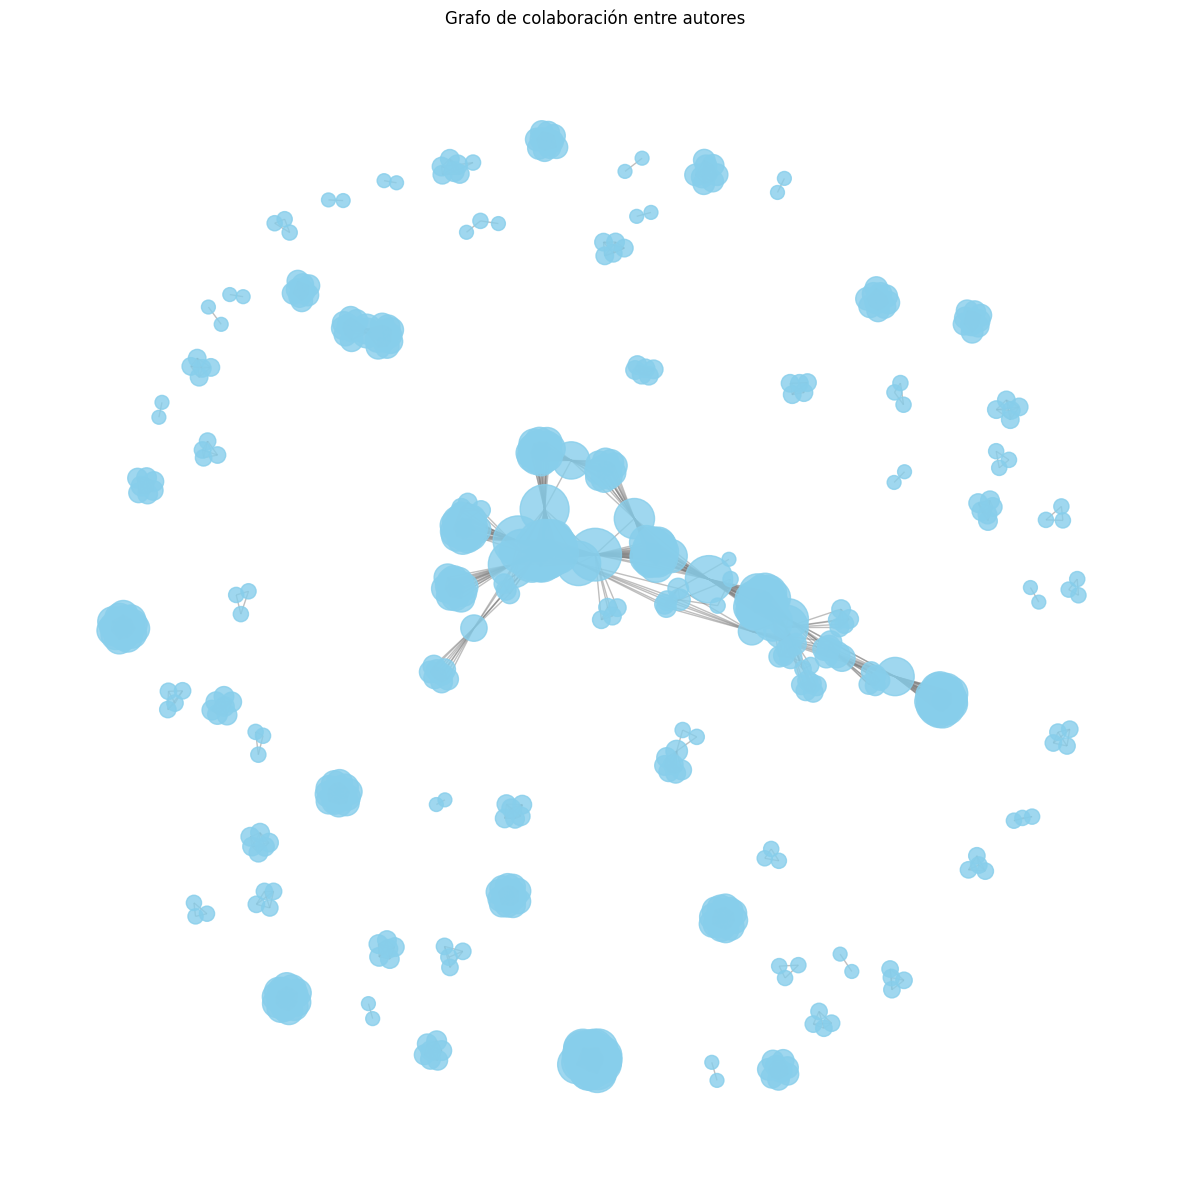

In [81]:
def visualize_graph(G):
    # Creamos directorio de figuras por si no existe
    os.makedirs(FIGURES_DIR, exist_ok=True) 
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, seed=42)
    node_sizes = [
        80 + (G.degree(node)*20)
        for node in G.nodes()
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        alpha=0.8,
        node_color="skyblue"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.5,
        edge_color="gray"
    )
    plt.title("Grafo de colaboración entre autores")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(FULL_GRAPH_IMAGE, format="PNG")
    plt.show()
    plt.close()

visualize_graph(G)

Ahora visualizamos los nodos más importantes según los criterios antes establecidos

In [ ]:
def visualize_important_nodes(G, df_centrality, top_n=20, save=True):
    os.makedirs(FIGURES_DIR, exist_ok=True) 
    # Conjunto de autores con mayor degree
    top_degree = set (df_centrality.nlargest(top_n, "degree_centrality")["authorId"])
     # Conjunto de autores con mayor betweeness
    top_betweenness = set (df_centrality.nlargest(top_n, "betweenness_centrality")["authorId"])
     # Conjunto de autores con closeness
    top_closeness = set (df_centrality.nlargest(top_n, "closeness_centrality")["authorId"]) 
    # Unión de todos los criterios
    important_nodes = top_degree|top_betweenness|top_closeness
    #Se crea un subgrafo con los nodos considerados más influyentes
    subgraph= G.subgraph(important_nodes).copy()
    degree_centrality = nx.degree_centrality(subgraph)
    #El tamaño de cada nodo se calcula de manera dinámica dependiendo de su centralidad en grados
    node_sizes = [300 + (degree_centrality[node]*300) for node in subgraph.nodes()]
    
    betweenness_centrality = nx.betweenness_centrality(subgraph,weight="distance")
    betweeness_values = [betweenness_centrality[node] for node in subgraph.nodes()]
    norm = mcolors.Normalize(vmin=min(betweeness_values), vmax=max(betweeness_values))
    node_colors = [cm.plasma(norm(v)) for v in betweeness_values]
    fig, ax = plt.subplots(figsize=(14, 14))
    pos= nx.spring_layout(subgraph, seed=42)
    nx.draw_networkx_nodes(
        subgraph,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.9,
        ax=ax
    )
    nx.draw_networkx_edges(
        subgraph,
        pos,
        alpha=0.7,
        edge_color="gray",
        ax=ax
    )
    labels = {node: get_author_name(G, node) for node in subgraph.nodes()}
    nx.draw_networkx_labels(subgraph, pos, labels, font_size=8)

    #Leyenda personalizada
    sm = plt.cm.ScalarMappable(cmap=cm.plasma, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Betweenness Centrality")
    ax.set_title(f"Autores más importantes (Top {top_n} en centralidad)")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(IMPORTANT_NODES_IMAGE, format="PNG",dpi=200)
    plt.show()
    plt.close()

    export_gexf(subgraph, GEXF_IMPORTANT_NODES_FILE)
    return subgraph

Ahora cargamos el archivo de centralidad y ejecutamos. Es importante compilar ese archivo pues los nodos estarán distribuidos de acuerdo con sus valores.
Un punto interesante a destacar es que usamos "distante" para el parámetro weigth dentro de la función de nx betweeness_centrality(), lo que modifica por completo la interpretación. Ahora, cada colaboración represente una relación más sólida y por ende un camino más "corto".

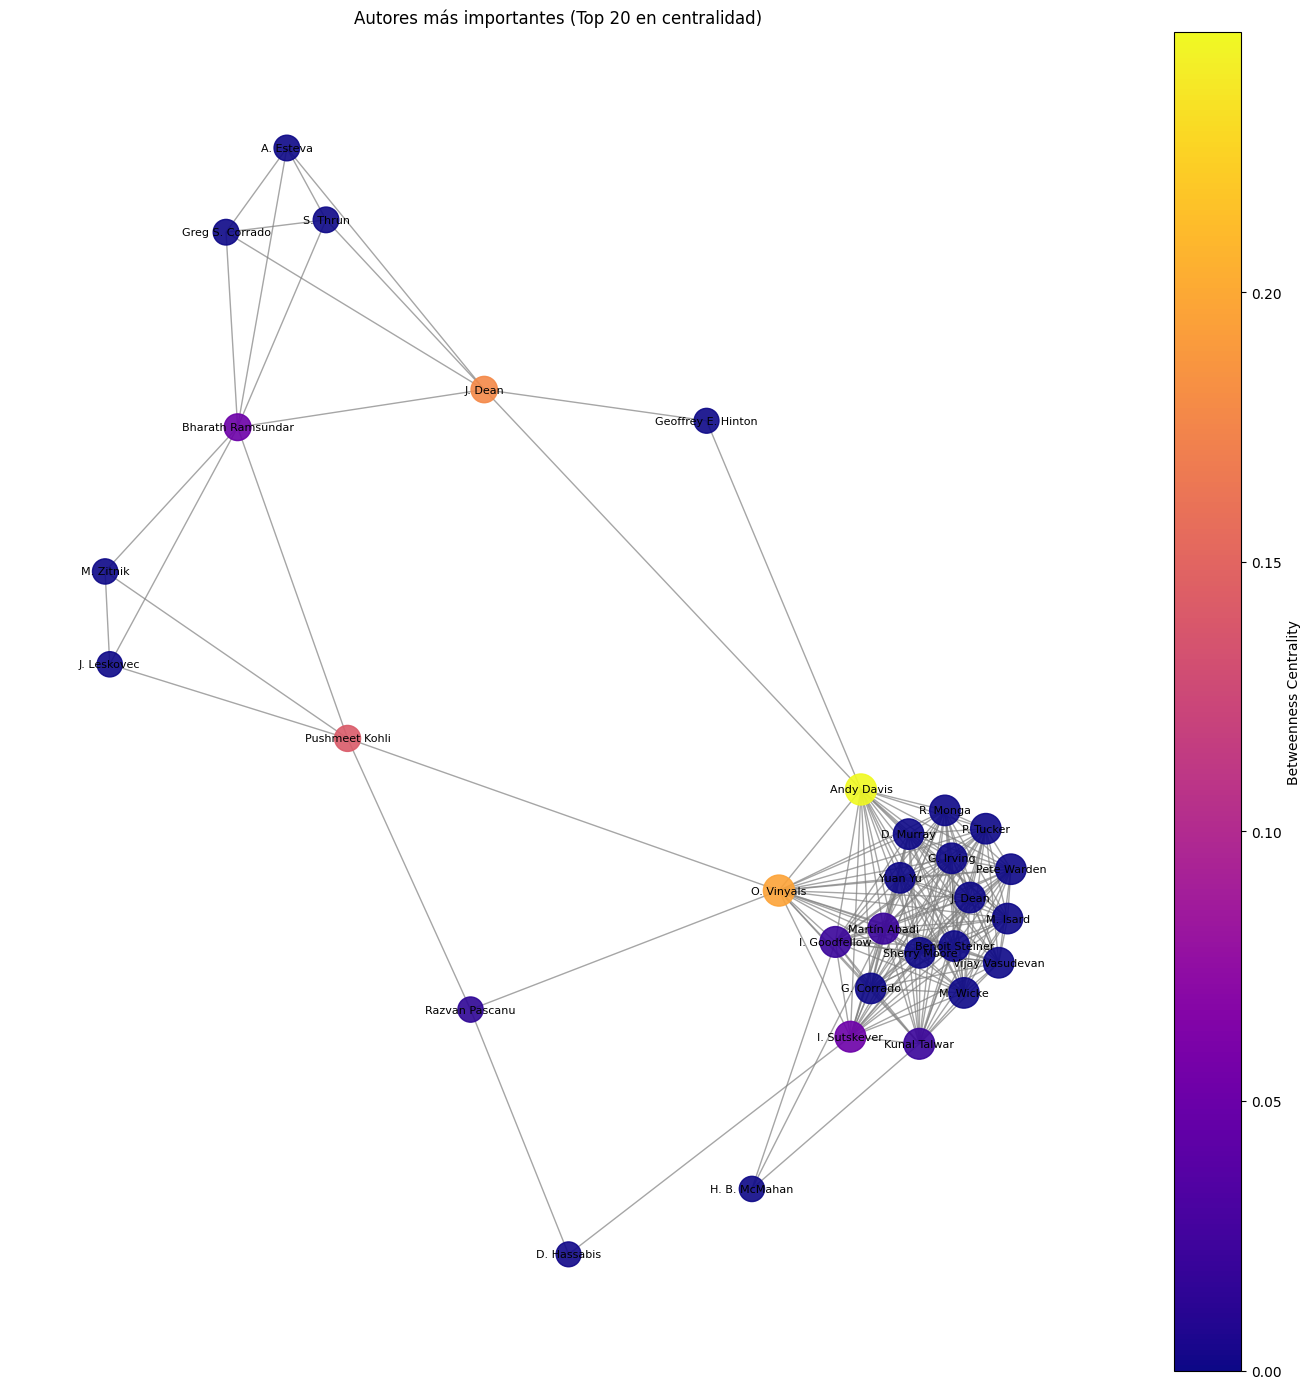

In [102]:
df_centrality = analyze_centrality(load_graph())  
visualize_important_nodes(G, df_centrality)  

Estos nodos representan las conexiones más importantes